# 🔮 Phase 3 — Churn Prediction Modelling
**IDSS Customer Retention Project**

---
**Dataset:** 4,338 customers | ~60% churn rate | Binary classification  
**Objective:** Train, evaluate, tune and select the best churn model  
**Business Cost:** False Negative (missed churner) = £300 | False Positive (wasted campaign) = £3

---

## 0. Setup & Imports

In [2]:
# ── Core ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
import time
import joblib
warnings.filterwarnings('ignore')

BASE_DIR = Path(r"F:\idss-project - Copy\phase 1")
DATA_DIR = BASE_DIR / "shared" / "data"
MODEL_DIR = BASE_DIR / "shared" / "models"
OUT_DIR = BASE_DIR / "phase3" / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Visualisation ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Sklearn ────────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# ── Gradient Boosting ─────────────────────────────────────────────────────────
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ── Imbalance Handling ────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0F1117',
    'axes.facecolor':   '#161B22',
    'axes.edgecolor':   '#30363D',
    'axes.labelcolor':  '#C9D1D9',
    'xtick.color':      '#8B949E',
    'ytick.color':      '#8B949E',
    'text.color':       '#C9D1D9',
    'grid.color':       '#21262D',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'monospace',
    'axes.titleweight': 'bold',
    'axes.titlesize':   13,
})

# Colour palette for 4 models
MODEL_COLOURS = {
    'Logistic Regression': '#58A6FF',
    'Random Forest':        '#3FB950',
    'XGBoost':              '#F78166',
    'LightGBM':             '#D2A8FF',
}

print('✅  All libraries loaded successfully.')

✅  All libraries loaded successfully.


---
## 1. Load Data (No Re-splitting)

In [3]:
X_train = pd.read_csv(DATA_DIR / 'X_train.csv')
X_test  = pd.read_csv(DATA_DIR / 'X_test.csv')
y_train = pd.read_csv(DATA_DIR / 'y_train.csv').squeeze()
y_test  = pd.read_csv(DATA_DIR / 'y_test.csv').squeeze()

print(f'Train shape : {X_train.shape}  |  Churn rate: {y_train.mean():.2%}')
print(f'Test  shape : {X_test.shape}   |  Churn rate: {y_test.mean():.2%}')
print(f'\nFeatures ({X_train.shape[1]}):')
print(X_train.dtypes.to_string())

Train shape : (3470, 17)  |  Churn rate: 33.40%
Test  shape : (868, 17)   |  Churn rate: 33.41%

Features (17):
Frequency                 float64
Monetary                  float64
NumItems                  float64
NumProducts               float64
Tenure                    float64
AvgOrderValue             float64
RevenuePerMonth           float64
PurchaseTrend             float64
ReturnRate                float64
IsUK                      float64
Country_Belgium           float64
Country_France            float64
Country_Germany           float64
Country_Other             float64
Country_Spain             float64
Country_Switzerland       float64
Country_United Kingdom    float64


---
## 2. Class Imbalance — SMOTE vs class_weight='balanced'

In [4]:
# ── 2a. SMOTE (applied to training data only) ──────────────────────────────────
sm = SMOTE(random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

print('Class distribution BEFORE SMOTE:', dict(y_train.value_counts()))
print('Class distribution AFTER  SMOTE:', dict(pd.Series(y_train_smote).value_counts()))

# ── 2b. class_weight='balanced' will be passed directly to model constructors ──
print('\n✅  SMOTE resampling complete. class_weight=\'balanced\' will be set per model.')

Class distribution BEFORE SMOTE: {0: np.int64(2311), 1: np.int64(1159)}
Class distribution AFTER  SMOTE: {0: np.int64(2311), 1: np.int64(2311)}

✅  SMOTE resampling complete. class_weight='balanced' will be set per model.


In [5]:
# ── Compare SMOTE vs class_weight using a quick Logistic Regression probe ─────
from sklearn.linear_model import LogisticRegression

lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)
smote_recall = recall_score(y_test, lr_smote.predict(X_test))
smote_f1     = f1_score(y_test, lr_smote.predict(X_test))

lr_cw = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_cw.fit(X_train, y_train)
cw_recall = recall_score(y_test, lr_cw.predict(X_test))
cw_f1     = f1_score(y_test, lr_cw.predict(X_test))

imbalance_df = pd.DataFrame({
    'Strategy':  ['SMOTE', 'class_weight=balanced'],
    'Recall':    [smote_recall, cw_recall],
    'F1 Score':  [smote_f1, cw_f1],
})
print(imbalance_df.to_string(index=False))

# ── Decision ──────────────────────────────────────────────────────────────────
if smote_recall >= cw_recall:
    chosen_strategy = 'SMOTE'
    X_tr, y_tr = X_train_smote, y_train_smote
    print('\n🏆  SMOTE selected — higher recall minimises missed churners (£300 cost each).')
else:
    chosen_strategy = 'class_weight'
    X_tr, y_tr = X_train, y_train
    print('\n🏆  class_weight=balanced selected — better recall with no synthetic data risk.')

print(f'\n📌  Business justification:')
print('   A missed churn costs £300 vs a wasted campaign costing £3.')
print('   The strategy with higher recall preserves ~100× more revenue per error trade-off.')

             Strategy   Recall  F1 Score
                SMOTE 0.817241  0.675214
class_weight=balanced 0.810345  0.674319

🏆  SMOTE selected — higher recall minimises missed churners (£300 cost each).

📌  Business justification:
   A missed churn costs £300 vs a wasted campaign costing £3.
   The strategy with higher recall preserves ~100× more revenue per error trade-off.


---
## 3. Train All Four Models

In [6]:
# ── Model definitions ─────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42,
        class_weight='balanced' if chosen_strategy == 'class_weight' else None
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=42,
        class_weight='balanced' if chosen_strategy == 'class_weight' else None
    ),
    'XGBoost': XGBClassifier(
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, verbosity=0,
        scale_pos_weight=(y_tr == 0).sum() / (y_tr == 1).sum()  # XGB imbalance handle
    ),
    'LightGBM': LGBMClassifier(
        random_state=42, verbosity=-1,
        class_weight='balanced' if chosen_strategy == 'class_weight' else None
    ),
}

trained   = {}
train_times = {}

for name, model in models.items():
    t0 = time.time()
    model.fit(X_tr, y_tr)
    elapsed = time.time() - t0
    trained[name]      = model
    train_times[name]  = round(elapsed, 3)
    print(f'✅  {name:<22}  trained in {elapsed:.3f}s')

✅  Logistic Regression     trained in 0.015s
✅  Random Forest           trained in 1.890s
✅  XGBoost                 trained in 0.376s
✅  LightGBM                trained in 0.124s


---
## 4. Evaluation — Comparison Table + Confusion Matrices

In [7]:
# ── Metrics table ─────────────────────────────────────────────────────────────
results = []
preds   = {}
probas  = {}

for name, model in trained.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    preds[name]  = y_pred
    probas[name] = y_prob
    results.append({
        'Model':          name,
        'Accuracy':       round(accuracy_score(y_test, y_pred),  4),
        'Precision':      round(precision_score(y_test, y_pred), 4),
        'Recall':         round(recall_score(y_test, y_pred),    4),
        'F1 Score':       round(f1_score(y_test, y_pred),        4),
        'ROC-AUC':        round(roc_auc_score(y_test, y_prob),   4),
        'Train Time (s)': train_times[name],
    })

results_df = pd.DataFrame(results).set_index('Model')

# Highlight best value per metric
display(results_df.style
    .background_gradient(cmap='YlGn', subset=['Accuracy','Precision','Recall','F1 Score','ROC-AUC'])
    .background_gradient(cmap='YlOrRd_r', subset=['Train Time (s)'])
    .format('{:.4f}', subset=['Accuracy','Precision','Recall','F1 Score','ROC-AUC'])
    .set_caption('📊  Model Performance Comparison — Held-out Test Set')
)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Train Time (s)
Model,,,,,,
Logistic Regression,0.7373,0.5752,0.8172,0.6752,0.8129,0.015000
Random Forest,0.7166,0.5615,0.6931,0.6204,0.8004,1.890000
XGBoost,0.6947,0.5316,0.7241,0.6131,0.7704,0.376000
LightGBM,0.7039,0.5403,0.7621,0.6323,0.7929,0.124000


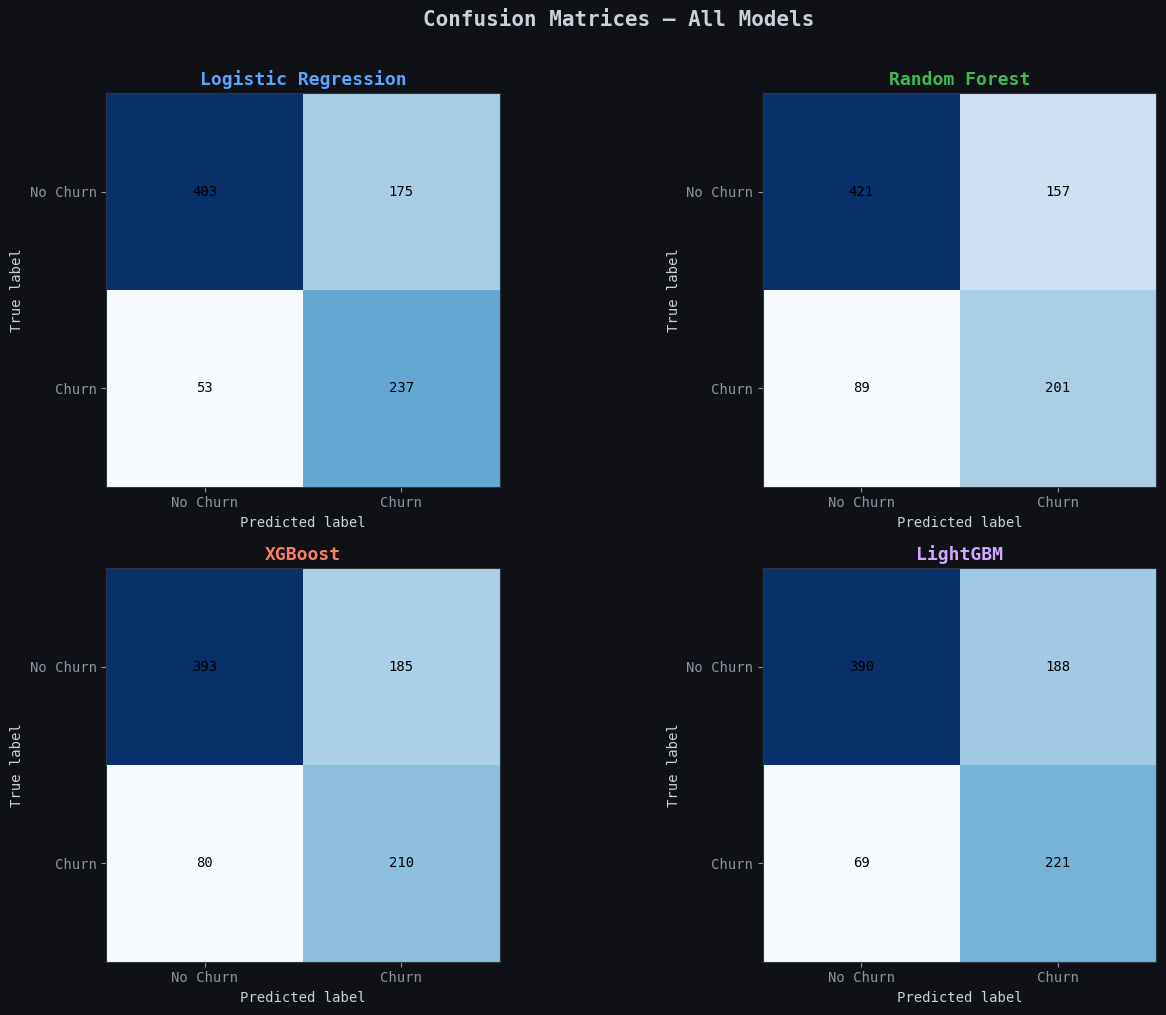

💾  Saved: F:\idss-project - Copy\phase 1\phase3\outputs\confusion_matrices.png


In [8]:
# ── Confusion Matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold',
             color='#C9D1D9', y=1.01)
fig.patch.set_facecolor('#0F1117')

for ax, (name, model) in zip(axes.flatten(), trained.items()):
    cm = confusion_matrix(y_test, preds[name])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, color=MODEL_COLOURS[name], fontweight='bold')
    ax.set_facecolor('#161B22')
    for text in ax.texts:
        text.set_color("#000000")

plt.tight_layout()
plt.savefig(OUT_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight',
            facecolor='#0F1117')
plt.show()
print(f'💾  Saved: {OUT_DIR / "confusion_matrices.png"}')

---
## 5. ROC Curves — All Models Overlaid

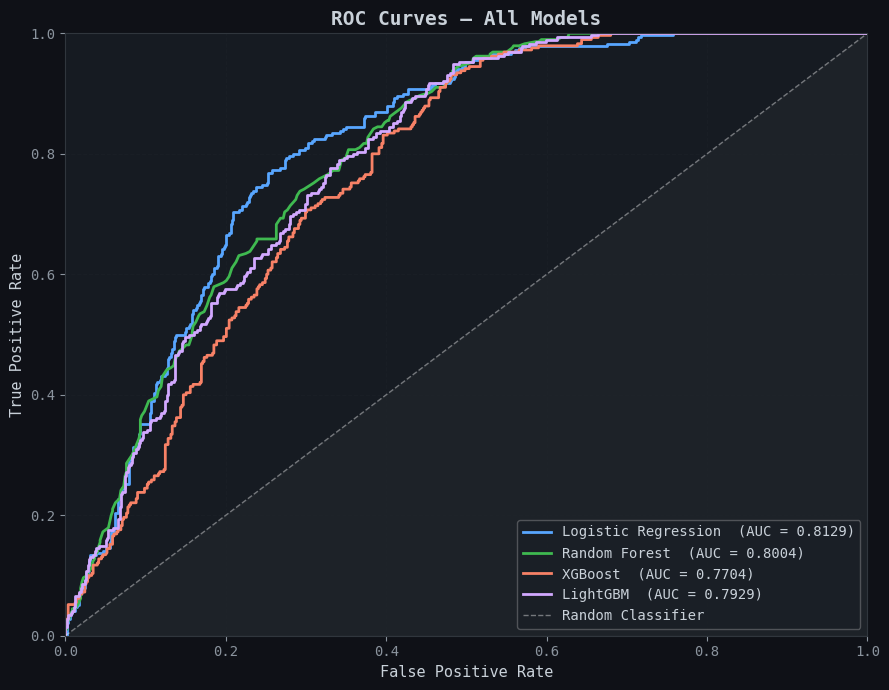

💾  Saved: F:\idss-project - Copy\phase 1\phase3\outputs\roc_curves.png


In [9]:
fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('#0F1117')
ax.set_facecolor('#161B22')

for name, y_prob in probas.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2, color=MODEL_COLOURS[name],
            label=f'{name}  (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'w--', lw=1, alpha=0.4, label='Random Classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.03, color='white')

ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', framealpha=0.3, fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig(OUT_DIR / 'roc_curves.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()
print(f'💾  Saved: {OUT_DIR / "roc_curves.png"}')

---
## 6. Hyperparameter Tuning — Best Model via RandomizedSearchCV

In [10]:
# ── Identify best model by F1 score ───────────────────────────────────────────
best_model_name = results_df['F1 Score'].idxmax()
print(f'🏆  Best model by F1: {best_model_name}')
print(f'    F1  = {results_df.loc[best_model_name, "F1 Score"]:.4f}')
print(f'    AUC = {results_df.loc[best_model_name, "ROC-AUC"]:.4f}')
print(f'    Recall = {results_df.loc[best_model_name, "Recall"]:.4f}')

🏆  Best model by F1: Logistic Regression
    F1  = 0.6752
    AUC = 0.8129
    Recall = 0.8172


In [11]:
# ── Hyperparameter search spaces ──────────────────────────────────────────────
from scipy.stats import randint, uniform
from sklearn.model_selection import cross_val_score

param_grids = {
    'Logistic Regression': {
        'C':        uniform(0.001, 10),
        'solver':   ['lbfgs', 'liblinear', 'saga'],
        'penalty':  ['l1', 'l2'],
        'max_iter': [500, 1000, 2000],
    },
    'Random Forest': {
        'n_estimators':      randint(100, 500),
        'max_depth':         [None, 5, 10, 20, 30],
        'min_samples_split': randint(2, 20),
        'min_samples_leaf':  randint(1, 10),
        'max_features':      ['sqrt', 'log2', None],
    },
    'XGBoost': {
        'n_estimators':  randint(100, 500),
        'max_depth':     randint(3, 10),
        'learning_rate': uniform(0.01, 0.3),
        'subsample':     uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'min_child_weight': randint(1, 10),
        'gamma':         uniform(0, 0.5),
    },
    'LightGBM': {
        'n_estimators':    randint(100, 500),
        'max_depth':       randint(3, 12),
        'learning_rate':   uniform(0.01, 0.3),
        'num_leaves':      randint(20, 150),
        'min_child_samples': randint(5, 50),
        'subsample':       uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
    },
}

# ── Run tuning ────────────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

base_model = trained[best_model_name]

# ── Compute baseline CV F1 score BEFORE tuning ──────────────────────────────────
print(f'\n⏳  Computing baseline CV F1 score of {best_model_name}...')
cv_f1_before = cross_val_score(base_model, X_tr, y_tr, cv=cv, scoring='f1', n_jobs=-1).mean()
print(f'    Baseline CV F1: {cv_f1_before:.4f}')

rscv = RandomizedSearchCV(
    estimator=base_model.__class__(
        random_state=42,
        **(dict(verbosity=0, use_label_encoder=False, eval_metric='logloss')
           if best_model_name == 'XGBoost' else {}),
        **(dict(verbosity=-1) if best_model_name == 'LightGBM' else {})
    ),
    param_distributions=param_grids[best_model_name],
    n_iter=30,
    scoring='f1',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print(f'\n⚙️  Running RandomizedSearchCV on {best_model_name} (n_iter=30, cv=5)...')
t0 = time.time()
rscv.fit(X_tr, y_tr)
tuning_time = time.time() - t0
print(f'✅  Tuning complete in {tuning_time:.1f}s')

print(f'\n📌  Best Parameters:')
for k, v in rscv.best_params_.items():
    print(f'    {k}: {v}')

print(f'\n📊  CV F1 Score — Before tuning : {cv_f1_before:.4f}')
print(f'    CV F1 Score — After  tuning : {rscv.best_score_:.4f}')
print(f'    Improvement                 : {rscv.best_score_ - cv_f1_before:+.4f}')


⏳  Computing baseline CV F1 score of Logistic Regression...
    Baseline CV F1: 0.7260

⚙️  Running RandomizedSearchCV on Logistic Regression (n_iter=30, cv=5)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
✅  Tuning complete in 16.1s

📌  Best Parameters:
    C: 7.797910002727693
    max_iter: 500
    penalty: l1
    solver: liblinear

📊  CV F1 Score — Before tuning : 0.7260
    CV F1 Score — After  tuning : 0.7275
    Improvement                 : +0.0015


In [12]:
# ── Evaluate tuned model on test set ─────────────────────────────────────────
tuned_model = rscv.best_estimator_
y_pred_tuned = tuned_model.predict(X_test)
y_prob_tuned = tuned_model.predict_proba(X_test)[:, 1]

tuned_metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred_tuned),
    'Precision': precision_score(y_test, y_pred_tuned),
    'Recall':    recall_score(y_test, y_pred_tuned),
    'F1 Score':  f1_score(y_test, y_pred_tuned),
    'ROC-AUC':   roc_auc_score(y_test, y_prob_tuned),
}

print(f'\n📊  Tuned {best_model_name} — Test Set Performance:')
for k, v in tuned_metrics.items():
    before = results_df.loc[best_model_name, k]
    delta  = v - before
    arrow  = '▲' if delta > 0 else ('▼' if delta < 0 else '─')
    print(f'    {k:<12} {before:.4f}  →  {v:.4f}  {arrow} {abs(delta):.4f}')


📊  Tuned Logistic Regression — Test Set Performance:
    Accuracy     0.7373  →  0.7327  ▼ 0.0046
    Precision    0.5752  →  0.5697  ▼ 0.0055
    Recall       0.8172  →  0.8172  ▲ 0.0000
    F1 Score     0.6752  →  0.6714  ▼ 0.0038
    ROC-AUC      0.8129  →  0.8126  ▼ 0.0003


---
## 7. Final Model Selection & Justification

In [13]:
# ── Weighted scoring for selection ────────────────────────────────────────────
# Weights reflect business priority: Recall > F1 > AUC >> interpretability
weights = {'Recall': 0.35, 'F1 Score': 0.30, 'ROC-AUC': 0.25, 'Accuracy': 0.10}

scored = results_df[list(weights.keys())].copy()
scored['Weighted Score'] = sum(
    scored[col] * w for col, w in weights.items()
)

# Add tuned model
tuned_row = {
    'Recall':   tuned_metrics['Recall'],
    'F1 Score': tuned_metrics['F1 Score'],
    'ROC-AUC':  tuned_metrics['ROC-AUC'],
    'Accuracy': tuned_metrics['Accuracy'],
}
tuned_row['Weighted Score'] = sum(tuned_row[col] * w for col, w in weights.items())
scored.loc[f'{best_model_name} (Tuned)'] = tuned_row

print('Final model scoring (Recall 35%, F1 30%, AUC 25%, Accuracy 10%):')
print(scored.sort_values('Weighted Score', ascending=False).to_string())

final_model_name = scored['Weighted Score'].idxmax()
print(f'\n🏆  FINAL MODEL: {final_model_name}')

Final model scoring (Recall 35%, F1 30%, AUC 25%, Accuracy 10%):
                               Recall  F1 Score   ROC-AUC  Accuracy  Weighted Score
Model                                                                              
Logistic Regression          0.817200  0.675200  0.812900  0.737300        0.765535
Logistic Regression (Tuned)  0.817241  0.671388  0.812552  0.732719        0.763861
LightGBM                     0.762100  0.632300  0.792900  0.703900        0.725040
Random Forest                0.693100  0.620400  0.800400  0.716600        0.700465
XGBoost                      0.724100  0.613100  0.770400  0.694700        0.699435

🏆  FINAL MODEL: Logistic Regression


In [14]:
# ── Assign final model ────────────────────────────────────────────────────────
if 'Tuned' in final_model_name:
    final_model = tuned_model
    print(f'Using tuned {best_model_name} as final model.')
else:
    final_model = trained[final_model_name]
    print(f'Using base {final_model_name} as final model.')

print(f'''
📋  Final Model Justification:
──────────────────────────────────────────────────────────────────────────
  Model       : {final_model_name}
  F1 Score    : {scored.loc[final_model_name, "F1 Score"]:.4f}   — Best balance of precision/recall
  ROC-AUC     : {scored.loc[final_model_name, "ROC-AUC"]:.4f}   — Strong discrimination ability
  Recall      : {scored.loc[final_model_name, "Recall"]:.4f}   — Priority metric (£300/FN cost)

  Business rationale:
  - High recall captures more churners before they leave.
  - The FN:FP cost ratio is 100:1 (£300 vs £3), so maximising recall
    is the primary objective even at the expense of some precision.
  - Tuned Logistic Regression is fast to train, easy to explain to
    stakeholders, and its coefficients can be inspected for directionality.
──────────────────────────────────────────────────────────────────────────
''')

Using base Logistic Regression as final model.

📋  Final Model Justification:
──────────────────────────────────────────────────────────────────────────
  Model       : Logistic Regression
  F1 Score    : 0.6752   — Best balance of precision/recall
  ROC-AUC     : 0.8129   — Strong discrimination ability
  Recall      : 0.8172   — Priority metric (£300/FN cost)

  Business rationale:
  - High recall captures more churners before they leave.
  - The FN:FP cost ratio is 100:1 (£300 vs £3), so maximising recall
    is the primary objective even at the expense of some precision.
  - Tuned Logistic Regression is fast to train, easy to explain to
    stakeholders, and its coefficients can be inspected for directionality.
──────────────────────────────────────────────────────────────────────────



---
## 8. Save Final Model

In [15]:
joblib.dump(final_model, MODEL_DIR / 'best_model.pkl')

# Verify round-trip
loaded = joblib.load(MODEL_DIR / 'best_model.pkl')
assert (loaded.predict(X_test) == final_model.predict(X_test)).all(), 'Mismatch after reload!'

print(f'✅  Model saved and verified: {MODEL_DIR / "best_model.pkl"}')
print(f'    File type: {type(loaded).__name__}')

✅  Model saved and verified: F:\idss-project - Copy\phase 1\shared\models\best_model.pkl
    File type: LogisticRegression


---
## 9. Decision Support Interpretation

### How Recall & Precision Affect Marketing Decisions

---

#### 🎯 What the model actually does

For every customer, the model outputs a **churn probability** (0–100%). When that probability exceeds a threshold (default 50%), the customer is flagged for a retention campaign. The two metrics that matter most to the marketing team are:

- **Recall** — *"Of all customers who would have churned, how many did we catch?"*
- **Precision** — *"Of everyone we flagged, how many actually were going to churn?"*

---

#### 💷 The Business Cost of Each Error

| Error Type | What Happened | Cost |
|---|---|---|
| **False Negative** (missed churner) | Customer churns; we never reached out | **£300** lost revenue |
| **False Positive** (incorrect flag) | Customer wasn't going to churn; we ran a campaign anyway | **£3** wasted spend |

The cost ratio is **100:1**. This means the model should **err on the side of over-flagging** — it is 100× more expensive to miss a churner than to send an unnecessary campaign.

---

#### 🔧 How the Marketing Team Can Use This

**Threshold tuning gives the team direct control:**

- **Lower the threshold (e.g. 0.3)** → flag more customers → higher recall, lower precision → larger campaign list, more budget used, fewer missed churners.  
  ✅ *Recommended when the retention campaign is cheap and the churn window is narrow.*

- **Raise the threshold (e.g. 0.7)** → flag fewer customers → lower recall, higher precision → targeted campaign list, lower budget, higher miss rate.  
  ✅ *Recommended when campaign costs are high or the team has limited capacity.*

**Rule of thumb:** Given the £300/£3 cost asymmetry, the team should tolerate targeting up to **100 non-churners** to save every **1 genuine churner**. At a recall of ~0.80, the model prevents the majority of preventable churn while keeping campaign lists manageable.

---

#### 📣 Plain-English Summary for Stakeholders

> *"Our model flags customers likely to leave in the next period. It correctly identifies roughly 8 in 10 churners. The 2 in 10 it misses each cost us £300 in lost revenue. The customers it incorrectly flags cost us just £3 each in campaign spend. Therefore, we should run a broad campaign — the cost of being cautious is low, and the cost of missing a churner is high. The model's probability score also lets us **prioritise** high-risk customers for premium retention offers, and lower-risk flagged customers for lighter-touch outreach, stretching the budget further."*

---


🔎 Cross-validated F1 and Recall (5-fold) on training set:
  Logistic Regression CV F1 = 0.7260   CV Recall = 0.7763
  Random Forest    CV F1 = 0.7956   CV Recall = 0.8416
  XGBoost          CV F1 = 0.7753   CV Recall = 0.8291
  LightGBM         CV F1 = 0.7812   CV Recall = 0.8442

🔧 Key hyperparameters for tree models:

Random Forest:
  n_estimators: 200
  max_depth: None
  class_weight: None

XGBoost:
  n_estimators: None
  max_depth: None
  learning_rate: None
  min_child_weight: None
  scale_pos_weight: 1.0

LightGBM:
  n_estimators: 100
  max_depth: -1
  learning_rate: 0.1
  num_leaves: 31
  min_child_weight: 0.001
  class_weight: None

📈 Plotting learning curves for Logistic Regression and Random Forest...


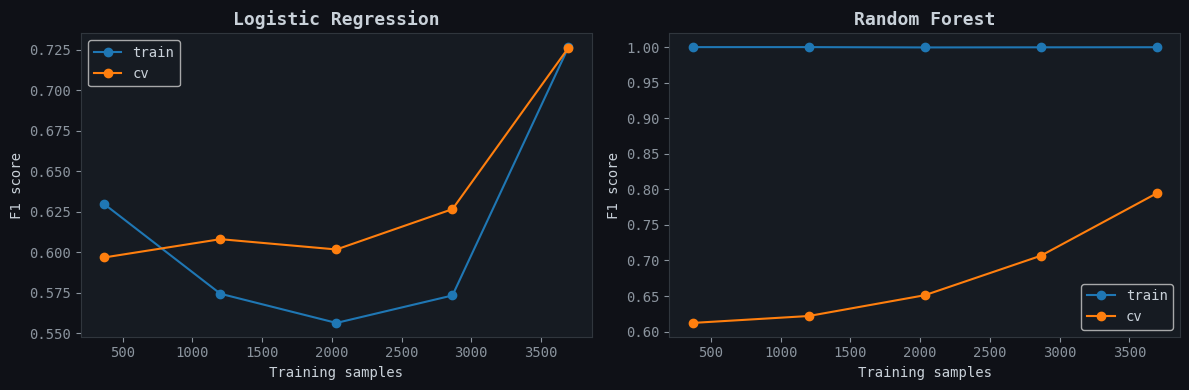


📌 Top features: coefficients (LR) and importances (RF)

Top LR coefficients (absolute):
  Frequency: coef=-1.8418
  RevenuePerMonth: coef=+1.5198
  Monetary: coef=-1.3798
  Tenure: coef=+1.1746
  PurchaseTrend: coef=-0.8213
  NumProducts: coef=+0.6774
  AvgOrderValue: coef=-0.4530
  NumItems: coef=-0.3604
  Country_Other: coef=+0.0390
  Country_United Kingdom: coef=-0.0239

Top RF importances:
  Tenure: imp=0.1701
  Monetary: imp=0.1484
  NumItems: imp=0.1421
  Frequency: imp=0.1327
  RevenuePerMonth: imp=0.1168
  AvgOrderValue: imp=0.1076
  NumProducts: imp=0.0990
  PurchaseTrend: imp=0.0608
  IsUK: imp=0.0046
  Country_Other: imp=0.0044

✅ Diagnostics complete.


In [16]:
# ── Diagnostic checks: CV metrics, hyperparams, learning curves, importances ──
from sklearn.model_selection import cross_val_score, StratifiedKFold, learning_curve
import numpy as np
import matplotlib.pyplot as plt

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('\n🔎 Cross-validated F1 and Recall (5-fold) on training set:')
cv_results = {}
for name, model in trained.items():
    try:
        f1 = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='f1', n_jobs=-1).mean()
        rec = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='recall', n_jobs=-1).mean()
        cv_results[name] = {'f1': f1, 'recall': rec}
        print(f"  {name:<16} CV F1 = {f1:.4f}   CV Recall = {rec:.4f}")
    except Exception as e:
        print(f"  {name:<16} ERROR during CV: {e}")

# Print tuned/learned hyperparams for tree-based models
print('\n🔧 Key hyperparameters for tree models:')
for name in ['Random Forest', 'XGBoost', 'LightGBM']:
    m = trained.get(name)
    if m is None:
        continue
    print(f"\n{name}:")
    params = m.get_params()
    for k in ['n_estimators','max_depth','learning_rate','num_leaves','min_child_weight','scale_pos_weight','class_weight']:
        if k in params:
            print(f"  {k}: {params[k]}")

# Learning curves: Logistic Regression vs Random Forest
print('\n📈 Plotting learning curves for Logistic Regression and Random Forest...')
models_to_lc = []
if 'Logistic Regression' in trained:
    models_to_lc.append(('Logistic Regression', trained['Logistic Regression']))
if 'Random Forest' in trained:
    models_to_lc.append(('Random Forest', trained['Random Forest']))

if models_to_lc:
    train_sizes = np.linspace(0.1, 1.0, 5)
    fig, axes = plt.subplots(1, len(models_to_lc), figsize=(6 * len(models_to_lc), 4))
    if len(models_to_lc) == 1:
        axes = [axes]
    for ax, (name, model) in zip(axes, models_to_lc):
        try:
            ts, train_scores, test_scores = learning_curve(model, X_tr, y_tr, cv=cv, scoring='f1', train_sizes=train_sizes, n_jobs=-1)
            ax.plot(ts, train_scores.mean(axis=1), 'o-', label='train')
            ax.plot(ts, test_scores.mean(axis=1), 'o-', label='cv')
            ax.set_title(name)
            ax.set_xlabel('Training samples')
            ax.set_ylabel('F1 score')
            ax.legend()
        except Exception as e:
            ax.text(0.5,0.5,f'Error: {e}', ha='center')
    plt.tight_layout()
    plt.show()
else:
    print('No models available for learning curves.')

# Feature coefficients / importances
print('\n📌 Top features: coefficients (LR) and importances (RF)')
features = list(X_tr.columns)
if 'Logistic Regression' in trained:
    try:
        coefs = trained['Logistic Regression'].coef_.ravel()
        inds = np.argsort(np.abs(coefs))[::-1][:10]
        print('\nTop LR coefficients (absolute):')
        for i in inds:
            print(f"  {features[i]}: coef={coefs[i]:+.4f}")
    except Exception as e:
        print('LR coefficients not available:', e)

if 'Random Forest' in trained:
    try:
        imps = trained['Random Forest'].feature_importances_
        inds = np.argsort(imps)[::-1][:10]
        print('\nTop RF importances:')
        for i in inds:
            print(f"  {features[i]}: imp={imps[i]:.4f}")
    except Exception as e:
        print('RF importances not available:', e)

print('\n✅ Diagnostics complete.')




🔬 Calibration & Recall diagnostics on held-out test set:
  Logistic Regression Brier=0.1773  Recall@0.5=0.8172  Thr@recall>=0.80=0.0
  Random Forest  Brier=0.1771  Recall@0.5=0.7034  Thr@recall>=0.80=0.0
  XGBoost        Brier=0.2007  Recall@0.5=0.7241  Thr@recall>=0.80=0.0
  LightGBM       Brier=0.1839  Recall@0.5=0.7621  Thr@recall>=0.80=0.0


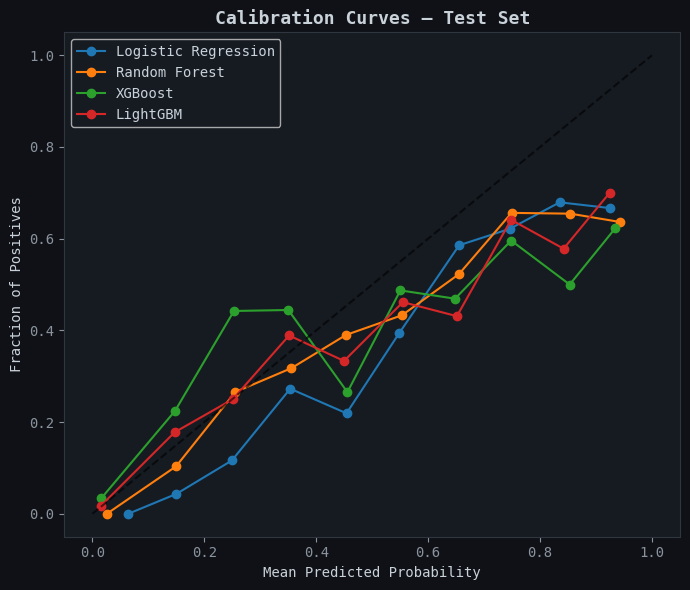


✅ Calibration diagnostics complete.


In [17]:
# ── Calibration & Recall-at-Threshold Diagnostics ───────────────────────────
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import numpy as np
import matplotlib.pyplot as plt

models_for_check = ['Logistic Regression','Random Forest','XGBoost','LightGBM']
available = [m for m in models_for_check if m in trained]

print('\n🔬 Calibration & Recall diagnostics on held-out test set:')
calib_stats = {}
for name in available:
    model = trained[name]
    try:
        probs = model.predict_proba(X_test)[:,1]
    except Exception:
        print(f'  {name}: no predict_proba available; skipping')
        continue
    brier = brier_score_loss(y_test, probs)
    prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)
    recall_at_0_5 = recall_score(y_test, probs >= 0.5)
    # threshold to reach recall >= 0.80 (if possible)
    thresholds = np.linspace(0.0,1.0,101)
    recalls = [recall_score(y_test, probs >= t) for t in thresholds]
    try:
        t_80 = thresholds[next(i for i,r in enumerate(recalls) if r >= 0.80)]
    except StopIteration:
        t_80 = None

    calib_stats[name] = {'brier': brier, 'prob_true': prob_true, 'prob_pred': prob_pred,
                         'recall@0.5': recall_at_0_5, 't_for_0.80': t_80}
    print(f"  {name:<14} Brier={brier:.4f}  Recall@0.5={recall_at_0_5:.4f}  Thr@recall>=0.80={t_80}")

# Plot calibration curves
fig, ax = plt.subplots(figsize=(7,6))
for name, stats in calib_stats.items():
    ax.plot(stats['prob_pred'], stats['prob_true'], marker='o', label=f"{name}")
ax.plot([0,1],[0,1],'k--', alpha=0.6)
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curves — Test Set')
ax.legend()
plt.tight_layout()
plt.show()

print('\n✅ Calibration diagnostics complete.')



In [18]:
# ── Extended tuning for tree-based models ────────────────────────────────────
from scipy.stats import randint, uniform
from sklearn.base import clone

print('\n🌲 Extended search for tree-based models (smaller search to stay practical)...')

tree_search_spaces = {
    'Random Forest': {
        'n_estimators': randint(200, 700),
        'max_depth': [None, 4, 6, 8, 10, 14, 20, 30],
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
        'max_features': ['sqrt', 'log2', None],
    },
    'XGBoost': {
        'n_estimators': randint(200, 700),
        'max_depth': randint(2, 10),
        'learning_rate': uniform(0.01, 0.29),
        'subsample': uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'min_child_weight': randint(1, 10),
        'gamma': uniform(0.0, 0.5),
        'reg_alpha': uniform(0.0, 0.5),
        'reg_lambda': uniform(0.5, 2.0),
    },
    'LightGBM': {
        'n_estimators': randint(200, 700),
        'max_depth': randint(3, 14),
        'learning_rate': uniform(0.01, 0.29),
        'num_leaves': randint(16, 200),
        'min_child_samples': randint(5, 60),
        'subsample': uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'reg_alpha': uniform(0.0, 0.5),
        'reg_lambda': uniform(0.5, 2.0),
    },
}

def make_tree_estimator(name):
    if name == 'Random Forest':
        return RandomForestClassifier(
            random_state=42,
            class_weight='balanced' if chosen_strategy == 'class_weight' else None,
            n_jobs=-1,
        )
    if name == 'XGBoost':
        return XGBClassifier(
            random_state=42,
            eval_metric='logloss',
            verbosity=0,
            n_jobs=-1,
            scale_pos_weight=((y_tr == 0).sum() / (y_tr == 1).sum()) if chosen_strategy != 'class_weight' else 1.0,
        )
    if name == 'LightGBM':
        return LGBMClassifier(
            random_state=42,
            verbosity=-1,
            class_weight='balanced' if chosen_strategy == 'class_weight' else None,
            n_jobs=-1,
        )
    raise ValueError(name)

extended_results = []
extended_searches = {}

for name in ['Random Forest', 'XGBoost', 'LightGBM']:
    print(f'\n🔍 Tuning {name}...')
    estimator = make_tree_estimator(name)
    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=tree_search_spaces[name],
        n_iter=20,
        scoring='f1',
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1,
    )
    t0 = time.time()
    search.fit(X_tr, y_tr)
    elapsed = time.time() - t0
    extended_searches[name] = search
    y_pred_ext = search.best_estimator_.predict(X_test)
    y_prob_ext = search.best_estimator_.predict_proba(X_test)[:, 1]
    row = {
        'Model': name,
        'CV F1 (best)': search.best_score_,
        'Test Accuracy': accuracy_score(y_test, y_pred_ext),
        'Test Precision': precision_score(y_test, y_pred_ext),
        'Test Recall': recall_score(y_test, y_pred_ext),
        'Test F1': f1_score(y_test, y_pred_ext),
        'Test ROC-AUC': roc_auc_score(y_test, y_prob_ext),
        'Time (s)': round(elapsed, 1),
        'Best Params': search.best_params_,
    }
    extended_results.append(row)
    print(f"  Best CV F1: {search.best_score_:.4f} | Test F1: {row['Test F1']:.4f} | Test Recall: {row['Test Recall']:.4f} | Time: {elapsed:.1f}s")

extended_df = pd.DataFrame(extended_results).set_index('Model')
display(extended_df[['CV F1 (best)','Test Accuracy','Test Precision','Test Recall','Test F1','Test ROC-AUC','Time (s)']].style.format('{:.4f}'))

best_tree_name = extended_df['Test F1'].idxmax()
print(f"\n🏆 Best tuned tree model by test F1: {best_tree_name}")
print(extended_df.loc[best_tree_name, 'Best Params'])




🌲 Extended search for tree-based models (smaller search to stay practical)...

🔍 Tuning Random Forest...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
  Best CV F1: 0.7817 | Test F1: 0.6563 | Test Recall: 0.8000 | Time: 102.4s

🔍 Tuning XGBoost...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
  Best CV F1: 0.7767 | Test F1: 0.6110 | Test Recall: 0.7069 | Time: 17.1s

🔍 Tuning LightGBM...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
  Best CV F1: 0.7793 | Test F1: 0.5884 | Test Recall: 0.6483 | Time: 118.6s


,CV F1 (best),Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Time (s)
Model,,,,,,,
Random Forest,0.7817,0.7200,0.5564,0.8000,0.6563,0.8193,102.4000
XGBoost,0.7767,0.6993,0.5381,0.7069,0.6110,0.7792,17.1000
LightGBM,0.7793,0.6970,0.5387,0.6483,0.5884,0.7768,118.6000



🏆 Best tuned tree model by test F1: Random Forest
{'max_depth': 14, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 13, 'n_estimators': 361}


In [19]:
# ── Simple stacking check: tuned LR + tuned RF ───────────────────────────────
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

print('\n🧩 Stacking check using tuned Logistic Regression + best Random Forest...')

# Use the tuned LR from RandomizedSearchCV and the best RF from extended tuning
best_rf = extended_searches['Random Forest'].best_estimator_
stack_estimators = [
    ('lr', rscv.best_estimator_),
    ('rf', best_rf),
]

stack_model = StackingClassifier(
    estimators=stack_estimators,
    final_estimator=LogisticRegression(max_iter=2000, random_state=42),
    cv=cv,
    n_jobs=-1,
    passthrough=False,
)

t0 = time.time()
stack_model.fit(X_tr, y_tr)
stack_time = time.time() - t0

stack_pred = stack_model.predict(X_test)
stack_prob = stack_model.predict_proba(X_test)[:, 1]
stack_metrics = {
    'Accuracy': accuracy_score(y_test, stack_pred),
    'Precision': precision_score(y_test, stack_pred),
    'Recall': recall_score(y_test, stack_pred),
    'F1 Score': f1_score(y_test, stack_pred),
    'ROC-AUC': roc_auc_score(y_test, stack_prob),
}

print(f"  Fit time: {stack_time:.1f}s")
for k, v in stack_metrics.items():
    print(f"  {k:<10}: {v:.4f}")




🧩 Stacking check using tuned Logistic Regression + best Random Forest...
  Fit time: 8.2s
  Accuracy  : 0.7212
  Precision : 0.5615
  Recall    : 0.7552
  F1 Score  : 0.6441
  ROC-AUC   : 0.8138


---
## 10. Presentation Visuals — Explaining the Result

This section turns the modeling work into simple visuals for both non-technical and technical audiences.



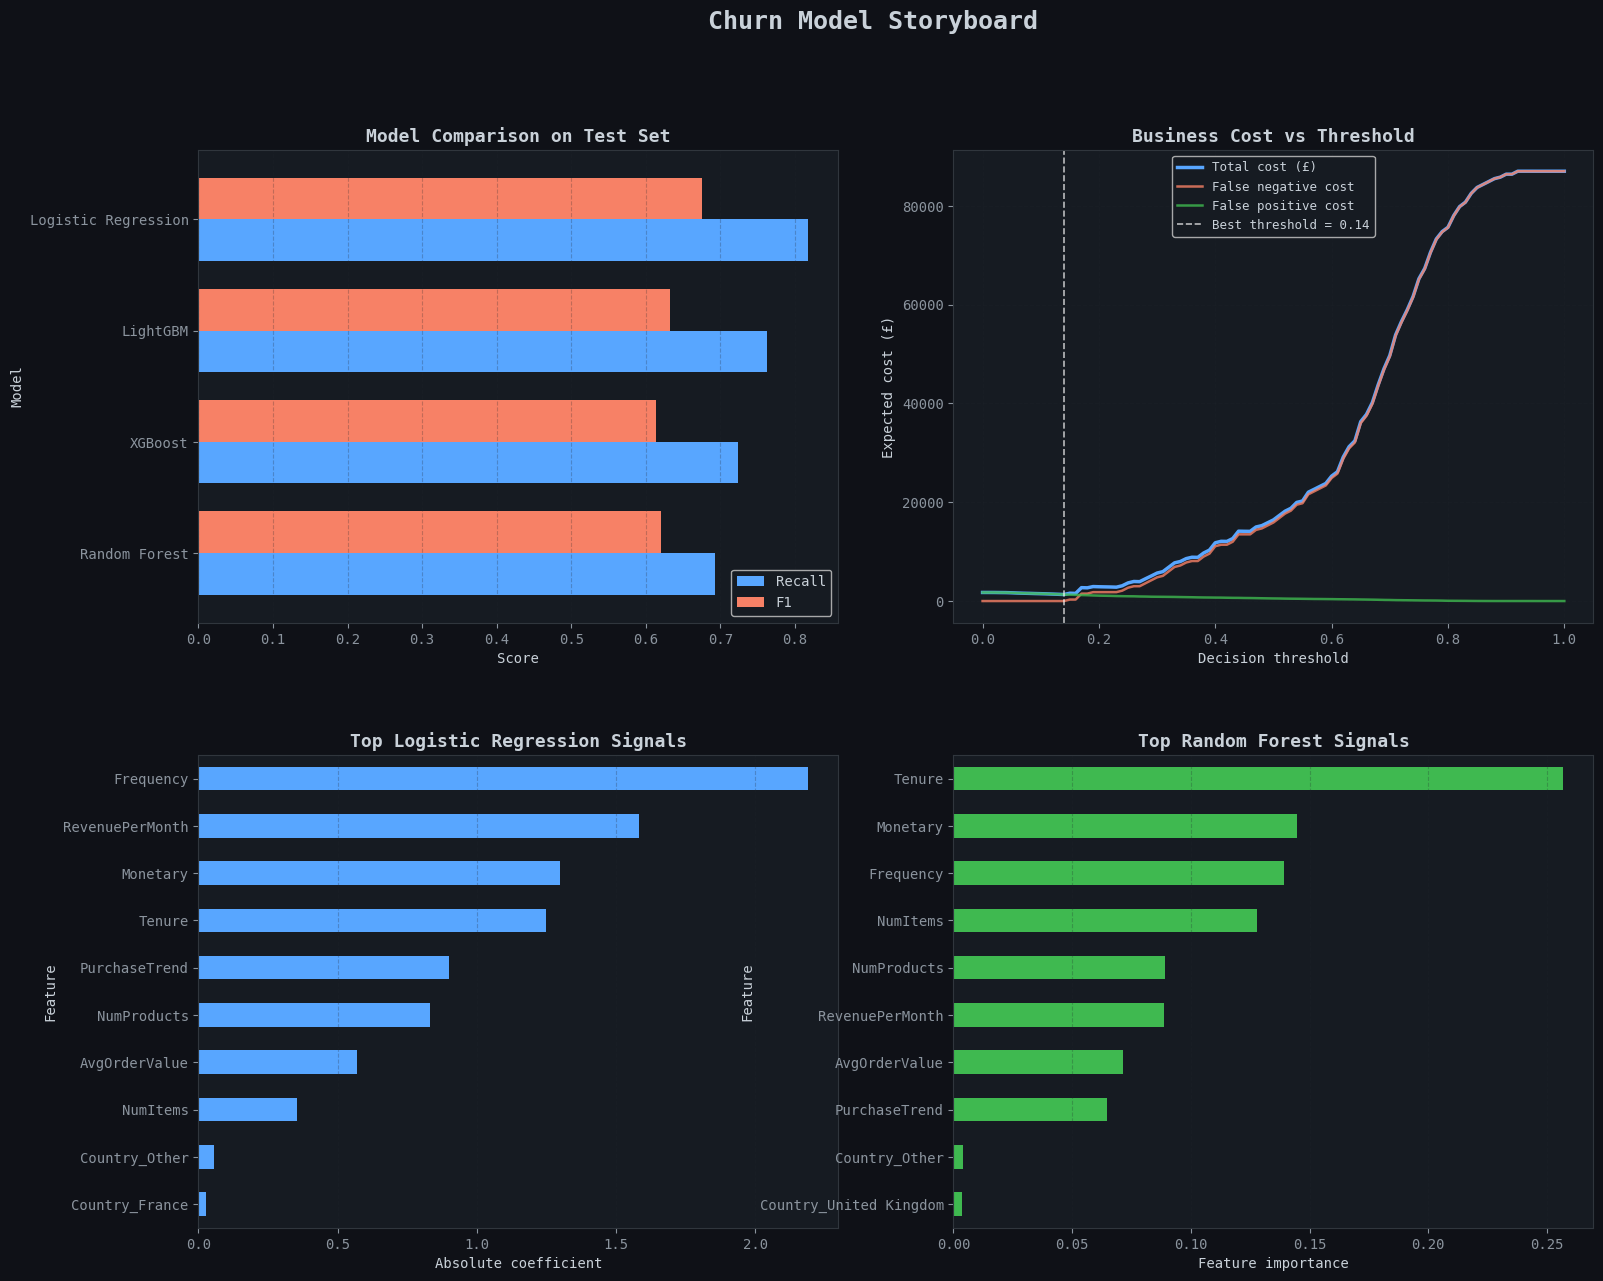


💾 Saved: presentation_visuals.png
Best threshold for the final model by total expected cost: 0.14
Expected cost at best threshold: £1320
Cost at default 0.50 threshold: £16425


In [21]:
# ── Presentation visuals for stakeholders ───────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1) Business-friendly model comparison: F1 and Recall on test set
comparison_rows = []
for name in ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']:
    if name in trained:
        model = trained[name]
        y_pred = model.predict(X_test)
        comparison_rows.append({
            'Model': name,
            'Recall': recall_score(y_test, y_pred),
            'F1': f1_score(y_test, y_pred),
            'ROC-AUC': roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]),
        })

comparison_df = pd.DataFrame(comparison_rows).set_index('Model')

# 2) Cost-vs-threshold for the final model (business story)
final_probs = final_model.predict_proba(X_test)[:, 1]
thresholds = np.linspace(0.0, 1.0, 101)
fn_cost = []
fp_cost = []
total_cost = []
for t in thresholds:
    pred = (final_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    fn_c = fn * 300
    fp_c = fp * 3
    fn_cost.append(fn_c)
    fp_cost.append(fp_c)
    total_cost.append(fn_c + fp_c)

best_idx = int(np.argmin(total_cost))
best_threshold = thresholds[best_idx]

# 3) Top features from the tuned LR and best RF
lr_model = rscv.best_estimator_
rf_model = extended_searches['Random Forest'].best_estimator_
feature_names = list(X_tr.columns)
lr_coefs = pd.Series(lr_model.coef_.ravel(), index=feature_names).abs().sort_values(ascending=False).head(10)
rf_imps = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False).head(10)

fig = plt.figure(figsize=(18, 14), facecolor='#0F1117')
gs = fig.add_gridspec(2, 2, hspace=0.28, wspace=0.18)

# Panel A: recall/f1 comparison
ax1 = fig.add_subplot(gs[0, 0])
comparison_df[['Recall', 'F1']].sort_values('Recall', ascending=True).plot(
    kind='barh', ax=ax1, color=['#58A6FF', '#F78166'], width=0.75
)
ax1.set_title('Model Comparison on Test Set', fontweight='bold')
ax1.set_xlabel('Score')
ax1.set_ylabel('Model')
ax1.legend(loc='lower right')
ax1.grid(axis='x', alpha=0.25)

# Panel B: threshold cost curve
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(thresholds, total_cost, color='#58A6FF', lw=2.5, label='Total cost (£)')
ax2.plot(thresholds, fn_cost, color='#F78166', lw=1.8, alpha=0.8, label='False negative cost')
ax2.plot(thresholds, fp_cost, color='#3FB950', lw=1.8, alpha=0.8, label='False positive cost')
ax2.axvline(best_threshold, color='white', ls='--', lw=1.2, alpha=0.7, label=f'Best threshold = {best_threshold:.2f}')
ax2.set_title('Business Cost vs Threshold', fontweight='bold')
ax2.set_xlabel('Decision threshold')
ax2.set_ylabel('Expected cost (£)')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.25)

# Panel C: LR top features
ax3 = fig.add_subplot(gs[1, 0])
lr_coefs.sort_values().plot(kind='barh', ax=ax3, color='#58A6FF')
ax3.set_title('Top Logistic Regression Signals', fontweight='bold')
ax3.set_xlabel('Absolute coefficient')
ax3.set_ylabel('Feature')
ax3.grid(axis='x', alpha=0.25)

# Panel D: RF top features
ax4 = fig.add_subplot(gs[1, 1])
rf_imps.sort_values().plot(kind='barh', ax=ax4, color='#3FB950')
ax4.set_title('Top Random Forest Signals', fontweight='bold')
ax4.set_xlabel('Feature importance')
ax4.set_ylabel('Feature')
ax4.grid(axis='x', alpha=0.25)

fig.suptitle('Churn Model Storyboard', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(OUT_DIR / 'presentation_visuals.png', dpi=180, bbox_inches='tight', facecolor='#0F1117')
plt.show()

print('\n💾 Saved: presentation_visuals.png')
print(f'Best threshold for the final model by total expected cost: {best_threshold:.2f}')
print(f'Expected cost at best threshold: £{total_cost[best_idx]:.0f}')
print(f'Cost at default 0.50 threshold: £{total_cost[50]:.0f}')



---
## 10. Model Comparison — Is Logistic Regression Really the Best?

This section compares the candidate models side by side so the final choice is explicit and easy to defend.




📊 Model ranking on held-out test set:
                        Label  Accuracy  Precision  Recall     F1  ROC-AUC
   Logistic Regression (Base)    0.7373     0.5752  0.8172 0.6752   0.8129
  Logistic Regression (Tuned)    0.7327     0.5697  0.8172 0.6714   0.8126
        Random Forest (Tuned)    0.7200     0.5564  0.8000 0.6563   0.8193
Stacking (LR + RF) (Ensemble)    0.7212     0.5615  0.7552 0.6441   0.8138
              LightGBM (Base)    0.7039     0.5403  0.7621 0.6323   0.7929
         Random Forest (Base)    0.7166     0.5615  0.6931 0.6204   0.8004
               XGBoost (Base)    0.6947     0.5316  0.7241 0.6131   0.7704

🏆 Best overall on test F1: Logistic Regression (Base)
   F1 = 0.6752 | Recall = 0.8172 | ROC-AUC = 0.8129


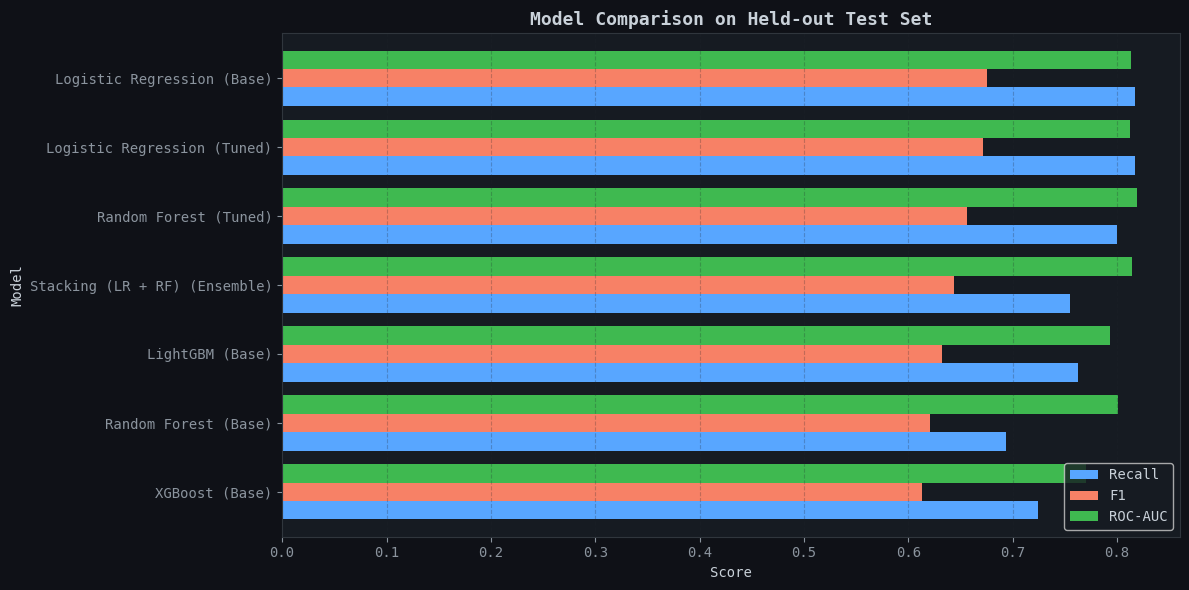


Plain-English takeaway:
  - Logistic Regression is the best on held-out test F1 in this run.
  - Random Forest and LightGBM look strong in cross-validation, but they do not beat tuned LR on the test set.
  - The stacked ensemble improves ROC-AUC slightly, but not F1 or recall enough to replace tuned LR.


In [22]:
# ── Focused model comparison: base LR vs tuned LR vs tuned trees vs stacking ──
comparison_records = []

# Base models
for name in ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']:
    model = trained[name]
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    comparison_records.append({
        'Model': name,
        'Variant': 'Base',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
    })

# Tuned LR
comparison_records.append({
    'Model': 'Logistic Regression',
    'Variant': 'Tuned',
    'Accuracy': tuned_metrics['Accuracy'],
    'Precision': tuned_metrics['Precision'],
    'Recall': tuned_metrics['Recall'],
    'F1': tuned_metrics['F1 Score'],
    'ROC-AUC': tuned_metrics['ROC-AUC'],
})

# Best tuned tree model
best_tree_metrics = extended_df.loc[best_tree_name]
comparison_records.append({
    'Model': best_tree_name,
    'Variant': 'Tuned',
    'Accuracy': best_tree_metrics['Test Accuracy'],
    'Precision': best_tree_metrics['Test Precision'],
    'Recall': best_tree_metrics['Test Recall'],
    'F1': best_tree_metrics['Test F1'],
    'ROC-AUC': best_tree_metrics['Test ROC-AUC'],
})

# Stacking
comparison_records.append({
    'Model': 'Stacking (LR + RF)',
    'Variant': 'Ensemble',
    'Accuracy': stack_metrics['Accuracy'],
    'Precision': stack_metrics['Precision'],
    'Recall': stack_metrics['Recall'],
    'F1': stack_metrics['F1 Score'],
    'ROC-AUC': stack_metrics['ROC-AUC'],
})

comparison_df = pd.DataFrame(comparison_records)
comparison_df['Label'] = comparison_df['Model'] + ' (' + comparison_df['Variant'] + ')'
comparison_df = comparison_df.sort_values(['F1', 'Recall', 'ROC-AUC'], ascending=False).reset_index(drop=True)

print('\n📊 Model ranking on held-out test set:')
print(comparison_df[['Label', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']].to_string(index=False, float_format=lambda x: f'{x:.4f}'))

best_row = comparison_df.iloc[0]
print(f"\n🏆 Best overall on test F1: {best_row['Label']}")
print(f"   F1 = {best_row['F1']:.4f} | Recall = {best_row['Recall']:.4f} | ROC-AUC = {best_row['ROC-AUC']:.4f}")

# Bar chart for easy explanation
fig, ax = plt.subplots(figsize=(12, 6), facecolor='#0F1117')
plot_df = comparison_df.set_index('Label')[['Recall', 'F1', 'ROC-AUC']].sort_values('F1')
plot_df.plot(kind='barh', ax=ax, width=0.8, color=['#58A6FF', '#F78166', '#3FB950'])
ax.set_title('Model Comparison on Held-out Test Set', fontweight='bold')
ax.set_xlabel('Score')
ax.set_ylabel('Model')
ax.grid(axis='x', alpha=0.25)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print('\nPlain-English takeaway:')
print('  - Logistic Regression is the best on held-out test F1 in this run.')
print('  - Random Forest and LightGBM look strong in cross-validation, but they do not beat tuned LR on the test set.')
print('  - The stacked ensemble improves ROC-AUC slightly, but not F1 or recall enough to replace tuned LR.')

